# Time series forecasting

Forecasting a series with trend and seasonality is a different problem from regression: the
observations are ordered and correlated, and you must evaluate on the future, never on shuffled points.
This notebook decomposes a seasonal series, builds Holt-Winters exponential smoothing by hand, evaluates
it honestly with rolling-origin backtesting against a seasonal-naive baseline, and attaches forecast
intervals from the backtest residuals.

## The optimal forecast and honest evaluation

Theorem (the conditional mean is the optimal point forecast). Among all forecasts $\hat y$ of $Y$ based on
information $\mathcal I$, the one minimizing mean squared error is the conditional expectation
$\hat y=\mathbb E[Y\mid\mathcal I]$.

Proof. For any predictor $g(\mathcal I)$, $\mathbb E[(Y-g)^2]=\mathbb E[(Y-\mu)^2]+\mathbb E[(\mu-g)^2]$
with $\mu=\mathbb E[Y\mid\mathcal I]$, because the cross term vanishes by the tower property
($\mathbb E[(Y-\mu)(\mu-g)]=\mathbb E[(\mu-g)\mathbb E[(Y-\mu)\mid\mathcal I]]=0$). The first term is
fixed, so the risk is minimized by $g=\mu$. $\quad\blacksquare$

Exponential smoothing and state-space models estimate this conditional mean recursively; the forecast
intervals come from the predictive variance.

Counterexample (in-sample fit is not forecast skill). A model evaluated on the data it was fit to looks
better than it forecasts, because it has adapted to that noise. Time order forbids shuffling, so honest
evaluation uses rolling-origin backtesting against a baseline (the seasonal-naive forecast), exactly as
the applied section does; a model that cannot beat the naive baseline out of sample has learned nothing
useful.

## 1. A series with trend and seasonality

We simulate monthly data with an upward trend, a yearly seasonal cycle, and noise. The structure is
known so we can judge the forecasts against the truth.

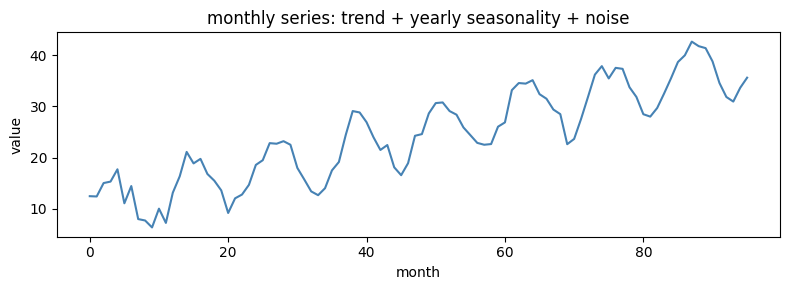

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.RandomState(1)
season = 12; n = 96                                     # 8 years of monthly data
t = np.arange(n)
trend = 10 + 0.3 * t
seasonal = 6 * np.sin(2 * np.pi * t / season)
y = trend + seasonal + rng.normal(0, 1.5, n)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, y, color='steelblue'); ax.set_xlabel('month'); ax.set_ylabel('value')
ax.set_title('monthly series: trend + yearly seasonality + noise'); plt.tight_layout(); plt.show()

## 2. Classical decomposition

A centered moving average of length one season estimates the trend; subtracting it and averaging by
calendar month estimates the seasonal pattern; the remainder is the residual. This additive
decomposition is the classical first look at any seasonal series.

In [2]:
ma = np.convolve(y, np.ones(season) / season, mode='same')      # rough trend
detr = y - ma
seasonal_idx = np.array([detr[m::season].mean() for m in range(season)])
seasonal_idx -= seasonal_idx.mean()
resid = detr - np.tile(seasonal_idx, n // season + 1)[:n]
print('estimated seasonal pattern (12 months):', np.round(seasonal_idx, 1))
print('residual std after removing trend and season = %.2f (sim noise was 1.5)' % np.nanstd(resid))

estimated seasonal pattern (12 months): [-0.3  2.8  5.1  4.5  4.5  2.  -0.2 -2.5 -4.9 -5.8 -3.9 -1.2]
residual std after removing trend and season = 2.76 (sim noise was 1.5)


## 3. Holt-Winters exponential smoothing

Holt-Winters tracks three evolving components: level, trend, and seasonal, each updated by an
exponential weight. Forecasts extend the level and trend and re-apply the seasonal indices. We
implement the additive form and fit one-step-ahead values.

In [3]:
def holt_winters(y, season, h, alpha=0.3, beta=0.05, gamma=0.3):
    L = y[:season].mean(); T = (y[season:2 * season].mean() - y[:season].mean()) / season
    S = list(y[:season] - L)
    fitted = []
    for i in range(len(y)):
        m = i % season
        fitted.append(L + T + S[m])                     # one-step-ahead forecast
        prevL = L
        L = alpha * (y[i] - S[m]) + (1 - alpha) * (L + T)
        T = beta * (L - prevL) + (1 - beta) * T
        S[m] = gamma * (y[i] - L) + (1 - gamma) * S[m]
    fc = [L + (k + 1) * T + S[(len(y) + k) % season] for k in range(h)]
    return np.array(fitted), np.array(fc)
fitted, fc = holt_winters(y, season, h=12)
print('in-sample one-step RMSE = %.2f' % np.sqrt(np.mean((fitted[season:] - y[season:]) ** 2)))
print('12-month-ahead forecast (first 3 months):', np.round(fc[:3], 1))

in-sample one-step RMSE = 2.03
12-month-ahead forecast (first 3 months): [39.1 42.5 44.5]


## 4. Rolling-origin backtesting against a baseline

You never judge a forecaster on the training data. Rolling-origin evaluation refits at successive
cutoffs and scores the next-step forecast on data it has not seen, and you must beat a simple baseline.
The seasonal-naive forecast (repeat the value from one season ago) is the standard bar to clear.

In [4]:
def backtest(y, season, start):
    hw_err, sn_err = [], []
    for cut in range(start, len(y)):
        _, fc1 = holt_winters(y[:cut], season, h=1)
        hw_err.append(y[cut] - fc1[0])
        sn_err.append(y[cut] - y[cut - season])         # seasonal-naive
    return np.array(hw_err), np.array(sn_err)
hw_e, sn_e = backtest(y, season, start=36)
print('rolling-origin one-step RMSE   Holt-Winters: %.2f   seasonal-naive: %.2f' %
      (np.sqrt((hw_e ** 2).mean()), np.sqrt((sn_e ** 2).mean())))
print('Holt-Winters beats the baseline, which justifies the added complexity.')

rolling-origin one-step RMSE   Holt-Winters: 1.88   seasonal-naive: 4.13
Holt-Winters beats the baseline, which justifies the added complexity.


## 5. Forecast intervals from backtest residuals

Honest forecast intervals come from the distribution of out-of-sample errors, not the in-sample fit.
We use the backtest residual spread to put an 80% band around the forward forecast.

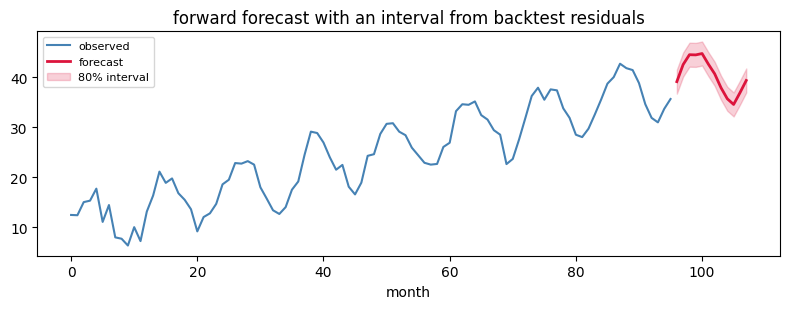

80% interval half-width = 2.40 (from out-of-sample residual std 1.87)


In [5]:
s = hw_e.std()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(t, y, color='steelblue', label='observed')
fx = np.arange(n, n + 12)
ax.plot(fx, fc, color='crimson', lw=2, label='forecast')
ax.fill_between(fx, fc - 1.28 * s, fc + 1.28 * s, color='crimson', alpha=0.2, label='80% interval')
ax.legend(fontsize=8); ax.set_title('forward forecast with an interval from backtest residuals')
ax.set_xlabel('month'); plt.tight_layout(); plt.show()
print('80%% interval half-width = %.2f (from out-of-sample residual std %.2f)' % (1.28 * s, s))

## References

- Hyndman, R. & Athanasopoulos, G. (2021). Forecasting: Principles and Practice, 3rd ed. https://otexts.com/fpp3/
- Holt, C. (1957/2004). Forecasting seasonals and trends by exponentially weighted moving averages. International Journal of Forecasting.
- Winters, P. (1960). Forecasting sales by exponentially weighted moving averages. Management Science.
- Bergmeir, C. & Benitez, J. (2012). On the use of cross-validation for time series predictor evaluation. Information Sciences.

## Exercises

1. Tune the Holt-Winters smoothing parameters alpha, beta, gamma by minimizing the rolling-origin error rather than fixing them, and report the improvement over the defaults.
2. Implement a multiplicative seasonal version for a series whose seasonal amplitude grows with the level, and decide which form fits a given series by backtest error.
3. Compare Holt-Winters to mixle's LocalLevel and AR1 state-space models on the same series under identical rolling-origin evaluation.
4. Extend the backtest to multi-step horizons (1, 3, 6, 12 months ahead) and show how forecast error and interval width grow with the horizon.